In [1]:
import pandas as pd

df = pd.read_csv("../data/customer_segmented.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1000, 10)


,name,age,gender,education,income,country,purchase_frequency,annual_spending,cluster,segment
0,Teresa Williams MD,42,Female,High School,53936,Slovenia,0.9,13227.120,1,Regular
1,Christine Myers,49,Female,Master,82468,Aruba,0.6,12674.040,0,Premium
2,Dwayne Moreno,55,Male,Bachelor,56941,Cyprus,0.3,5354.115,2,Budget
3,Amy Norton,24,Female,Bachelor,60651,Palau,0.2,2606.510,2,Budget
4,Tonya Adams,64,Male,Master,81884,Zambia,0.9,18984.780,0,Premium


In [2]:
def generate_customer_recommendation(customer):
    
    segment = customer["segment"]
    purchase_frequency = customer["purchase_frequency"]
    annual_spending = customer["annual_spending"]
    
    recommendations = []
    
    if segment == "Premium":
        recommendations.append(
            "Offer exclusive premium products and personalized deals."
        )
        recommendations.append(
            "Provide loyalty rewards and early access to new products."
        )
        
        if purchase_frequency >= 0.8:
            recommendations.append(
                "Maintain engagement with frequent personalized campaigns."
            )
        else:
            recommendations.append(
                "Use targeted offers to increase purchase frequency."
            )
    
    elif segment == "Regular":
        recommendations.append(
            "Provide targeted discounts and product recommendations."
        )
        recommendations.append(
            "Use loyalty programs to encourage repeat purchases."
        )
        
        if purchase_frequency < 0.7:
            recommendations.append(
                "Offer incentives to increase purchase frequency."
            )
        else:
            recommendations.append(
                "Maintain engagement with personalized promotions."
            )
    
    elif segment == "Budget":
        recommendations.append(
            "Promote affordable products and value-for-money offers."
        )
        recommendations.append(
            "Provide discounts, bundles, and seasonal promotions."
        )
        
        if annual_spending < 5000:
            recommendations.append(
                "Use low-cost promotional offers to encourage purchases."
            )
        else:
            recommendations.append(
                "Gradually encourage higher-value purchases through bundles."
            )
    
    return recommendations

In [3]:
customer = df.iloc[1]

print("Customer:", customer["name"])
print("Segment:", customer["segment"])
print()

print("Recommendations:")

recommendations = generate_customer_recommendation(customer)

for i, recommendation in enumerate(recommendations, 1):
    print(f"{i}. {recommendation}")

Customer: Christine Myers
Segment: Premium

Recommendations:
1. Offer exclusive premium products and personalized deals.
2. Provide loyalty rewards and early access to new products.
3. Use targeted offers to increase purchase frequency.


In [4]:
def get_segment_strategy(segment):
    
    strategies = {
        "Premium": {
            "strategy": "Retain & Reward",
            "goal": "Increase customer loyalty and lifetime value",
            "actions": [
                "Offer exclusive premium products",
                "Provide loyalty rewards and VIP benefits",
                "Give early access to new products",
                "Send personalized offers based on customer behavior"
            ]
        },
        
        "Regular": {
            "strategy": "Engage & Upsell",
            "goal": "Increase purchase frequency and average spending",
            "actions": [
                "Provide targeted discounts",
                "Recommend related products",
                "Introduce loyalty programs",
                "Offer incentives for repeat purchases"
            ]
        },
        
        "Budget": {
            "strategy": "Convert & Increase Value",
            "goal": "Increase engagement and gradually improve spending",
            "actions": [
                "Promote affordable products",
                "Offer value-for-money bundles",
                "Provide seasonal discounts",
                "Encourage repeat purchases through promotional offers"
            ]
        }
    }
    
    return strategies.get(segment)

In [5]:
for segment in ["Premium", "Regular", "Budget"]:
    
    strategy = get_segment_strategy(segment)
    
    print("=" * 50)
    print("SEGMENT:", segment)
    print("STRATEGY:", strategy["strategy"])
    print("BUSINESS GOAL:", strategy["goal"])
    print("ACTIONS:")
    
    for action in strategy["actions"]:
        print("-", action)

SEGMENT: Premium
STRATEGY: Retain & Reward
BUSINESS GOAL: Increase customer loyalty and lifetime value
ACTIONS:
- Offer exclusive premium products
- Provide loyalty rewards and VIP benefits
- Give early access to new products
- Send personalized offers based on customer behavior
SEGMENT: Regular
STRATEGY: Engage & Upsell
BUSINESS GOAL: Increase purchase frequency and average spending
ACTIONS:
- Provide targeted discounts
- Recommend related products
- Introduce loyalty programs
- Offer incentives for repeat purchases
SEGMENT: Budget
STRATEGY: Convert & Increase Value
BUSINESS GOAL: Increase engagement and gradually improve spending
ACTIONS:
- Promote affordable products
- Offer value-for-money bundles
- Provide seasonal discounts
- Encourage repeat purchases through promotional offers


In [6]:
def generate_customer_insights(customer):
    
    segment = customer["segment"]
    
    recommendations = generate_customer_recommendation(customer)
    strategy = get_segment_strategy(segment)
    
    insights = {
        "customer_name": customer["name"],
        "segment": segment,
        "strategy": strategy["strategy"],
        "business_goal": strategy["goal"],
        "recommendations": recommendations,
        "actions": strategy["actions"]
    }
    
    return insights

In [7]:
customer = df.iloc[1]

insights = generate_customer_insights(customer)

print("Customer:", insights["customer_name"])
print("Segment:", insights["segment"])
print("Strategy:", insights["strategy"])
print("Business Goal:", insights["business_goal"])

print("\nCustomer-Specific Recommendations:")

for i, recommendation in enumerate(insights["recommendations"], 1):
    print(f"{i}. {recommendation}")

print("\nSegment-Specific Actions:")

for i, action in enumerate(insights["actions"], 1):
    print(f"{i}. {action}")

Customer: Christine Myers
Segment: Premium
Strategy: Retain & Reward
Business Goal: Increase customer loyalty and lifetime value

Customer-Specific Recommendations:
1. Offer exclusive premium products and personalized deals.
2. Provide loyalty rewards and early access to new products.
3. Use targeted offers to increase purchase frequency.

Segment-Specific Actions:
1. Offer exclusive premium products
2. Provide loyalty rewards and VIP benefits
3. Give early access to new products
4. Send personalized offers based on customer behavior


In [8]:
def create_recommendation_text(customer):
    recommendations = generate_customer_recommendation(customer)
    return " ".join(recommendations)


def create_strategy_text(customer):
    strategy = get_segment_strategy(customer["segment"])
    return strategy["strategy"]


def create_goal_text(customer):
    strategy = get_segment_strategy(customer["segment"])
    return strategy["goal"]


df["recommendations"] = df.apply(create_recommendation_text, axis=1)
df["strategy"] = df.apply(create_strategy_text, axis=1)
df["business_goal"] = df.apply(create_goal_text, axis=1)

print("Recommendations generated for all customers.")

Recommendations generated for all customers.


In [9]:
recommendation_data = df[
    [
        "name",
        "age",
        "income",
        "purchase_frequency",
        "annual_spending",
        "segment",
        "strategy",
        "business_goal",
        "recommendations"
    ]
]

recommendation_data.head()

,name,age,income,purchase_frequency,annual_spending,segment,strategy,business_goal,recommendations
0,Teresa Williams MD,42,53936,0.9,13227.120,Regular,Engage & Upsell,Increase purchase frequency and average spending,Provide targeted discounts and product recomme...
1,Christine Myers,49,82468,0.6,12674.040,Premium,Retain & Reward,Increase customer loyalty and lifetime value,Offer exclusive premium products and personali...
2,Dwayne Moreno,55,56941,0.3,5354.115,Budget,Convert & Increase Value,Increase engagement and gradually improve spen...,Promote affordable products and value-for-mone...
3,Amy Norton,24,60651,0.2,2606.510,Budget,Convert & Increase Value,Increase engagement and gradually improve spen...,Promote affordable products and value-for-mone...
4,Tonya Adams,64,81884,0.9,18984.780,Premium,Retain & Reward,Increase customer loyalty and lifetime value,Offer exclusive premium products and personali...


In [10]:
recommendation_data.to_csv(
    "../data/customer_recommendations.csv",
    index=False
)

print("Customer recommendations saved successfully!")

Customer recommendations saved successfully!


In [11]:
strategy_summary = (
    df.groupby("segment")
      .agg(
          customer_count=("name", "count"),
          average_income=("income", "mean"),
          average_spending=("annual_spending", "mean"),
          average_purchase_frequency=("purchase_frequency", "mean")
      )
      .round(2)
)

strategy_summary

,customer_count,average_income,average_spending,average_purchase_frequency
segment,,,,
Budget,446,57163.59,4633.07,0.29
Premium,292,80638.28,13829.13,0.76
Regular,262,39070.67,13392.53,0.78


In [12]:
strategy_summary.to_csv(
    "../data/segment_strategy_summary.csv"
)

print("Segment strategy summary saved successfully!")

Segment strategy summary saved successfully!


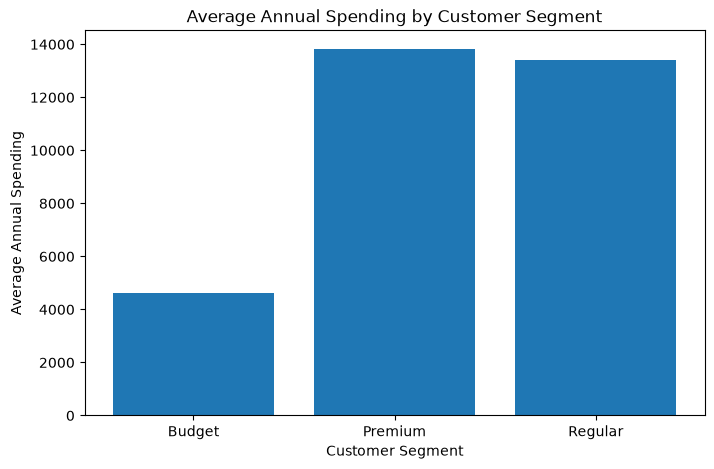

In [13]:
import matplotlib.pyplot as plt

segment_spending = df.groupby("segment")["annual_spending"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    segment_spending.index,
    segment_spending.values
)

plt.title("Average Annual Spending by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Annual Spending")

plt.show()

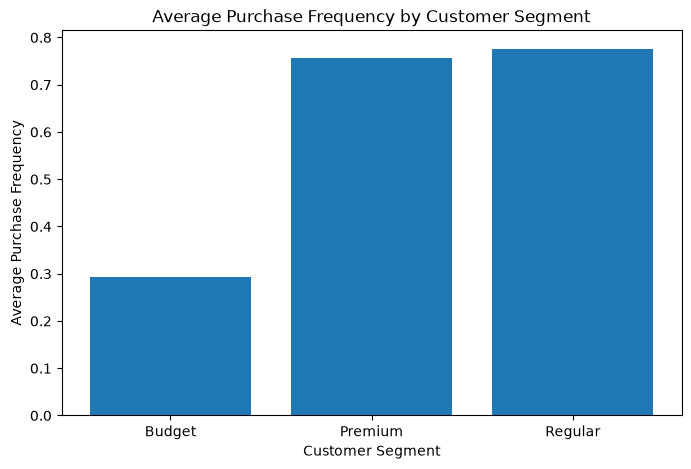

In [14]:
segment_frequency = df.groupby("segment")["purchase_frequency"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    segment_frequency.index,
    segment_frequency.values
)

plt.title("Average Purchase Frequency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Purchase Frequency")

plt.show()

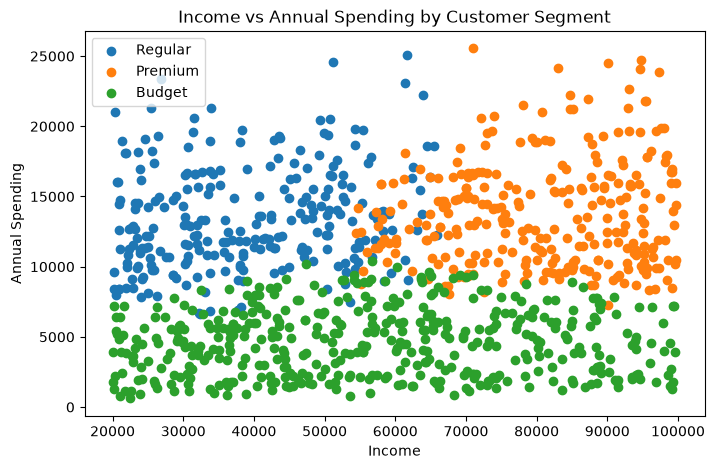

In [15]:
plt.figure(figsize=(8, 5))

for segment in df["segment"].unique():
    segment_data = df[df["segment"] == segment]

    plt.scatter(
        segment_data["income"],
        segment_data["annual_spending"],
        label=segment
    )

plt.title("Income vs Annual Spending by Customer Segment")
plt.xlabel("Income")
plt.ylabel("Annual Spending")
plt.legend()

plt.show()

## Phase 6 — AI Recommendation Insights

The customer segmentation model divides customers into Premium, Regular, and Budget segments based on age, income, purchase frequency, and annual spending.

### Premium Customers
- Higher average income
- High purchase frequency
- High annual spending
- Strategy: Retain and reward
- Recommendations: Exclusive products, loyalty rewards, early access, personalized offers

### Regular Customers
- High purchase frequency
- Significant annual spending
- Opportunity for upselling and cross-selling
- Strategy: Increase customer value
- Recommendations: Product bundles, personalized discounts, loyalty programs

### Budget Customers
- Lower purchase frequency
- Lower annual spending
- Strategy: Increase engagement and conversion
- Recommendations: Affordable products, discounts, promotional campaigns

### Key Business Insight

Regular customers represent an important growth opportunity because they demonstrate high purchase frequency and substantial spending, creating potential for upselling and cross-selling.

In [16]:
import sys
sys.path.append("../src")

from recommendation_engine import generate_recommendations

result = generate_recommendations("Premium")

print("Strategy:")
print(result["strategy"])

print("\nRecommendations:")

for recommendation in result["recommendations"]:
    print("-", recommendation)

Strategy:
Retain and reward high-value customers

Recommendations:
- Offer exclusive premium products and personalized deals.
- Provide loyalty rewards and early access to new products.
- Use targeted offers to increase purchase frequency.


In [17]:
import sys

sys.path.append("../src")

from prediction_pipeline import analyze_customer

In [18]:
result = analyze_customer(
    age=30,
    income=1200000,
    purchase_frequency=0.8,
    annual_spending=150000
)

print("Customer Segment:")
print(result["segment"])

print("\nStrategy:")
print(result["strategy"])

print("\nRecommendations:")

for recommendation in result["recommendations"]:
    print("-", recommendation)

Customer Segment:
Premium

Strategy:
Retain and reward high-value customers

Recommendations:
- Offer exclusive premium products and personalized deals.
- Provide loyalty rewards and early access to new products.
- Use targeted offers to increase purchase frequency.


In [19]:
result = analyze_customer(
    age=30,
    income=1200000,
    purchase_frequency=0.8,
    annual_spending=150000
)

print(result)

{'segment': 'Premium', 'strategy': 'Retain and reward high-value customers', 'recommendations': ['Offer exclusive premium products and personalized deals.', 'Provide loyalty rewards and early access to new products.', 'Use targeted offers to increase purchase frequency.']}


In [20]:
result = analyze_customer(
    age=25,
    income=400000,
    purchase_frequency=0.2,
    annual_spending=3000
)

print(result)

{'segment': 'Budget', 'strategy': 'Increase engagement and encourage conversion', 'recommendations': ['Offer affordable products and value-for-money deals.', 'Use discounts and promotional campaigns to increase purchases.', 'Recommend products based on previous purchasing behavior.']}


In [21]:
result = analyze_customer(
    age=45,
    income=600000,
    purchase_frequency=0.7,
    annual_spending=12000
)

print(result)

{'segment': 'Premium', 'strategy': 'Retain and reward high-value customers', 'recommendations': ['Offer exclusive premium products and personalized deals.', 'Provide loyalty rewards and early access to new products.', 'Use targeted offers to increase purchase frequency.']}


In [22]:
import sys

# Allow Python to find files inside src/
sys.path.append("../src")

from prediction_pipeline import analyze_customer


# Test customer
result = analyze_customer(
    age=30,
    income=1200000,
    purchase_frequency=0.8,
    annual_spending=150000
)


# Display result
print("Customer Segment:")
print(result["segment"])

print("\nStrategy:")
print(result["strategy"])

print("\nRecommendations:")

for recommendation in result["recommendations"]:
    print("-", recommendation)

Customer Segment:
Premium

Strategy:
Retain and reward high-value customers

Recommendations:
- Offer exclusive premium products and personalized deals.
- Provide loyalty rewards and early access to new products.
- Use targeted offers to increase purchase frequency.
